In [4]:
import torch
from torch import nn
from torch.nn import functional as F


In [5]:
import kagglehub
path = kagglehub.dataset_download("shivamb/netflix-shows")

Using Colab cache for faster access to the 'netflix-shows' dataset.


In [6]:
import pandas as pd
df = pd.read_csv(path + "/netflix_titles.csv")
print(df.shape)   # number of rows, columns
print(df.info())
df.head()

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
print("Nombre d'échantillons:", len(df))
print("Nombre de variables:", len(df.columns))
print(df.dtypes)  # type de chaque variable


Nombre d'échantillons: 8807
Nombre de variables: 12
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


type
Movie      0.696151
TV Show    0.303849
Name: proportion, dtype: float64


<Axes: title={'center': 'Distribution Movie vs TV Show'}, xlabel='type'>

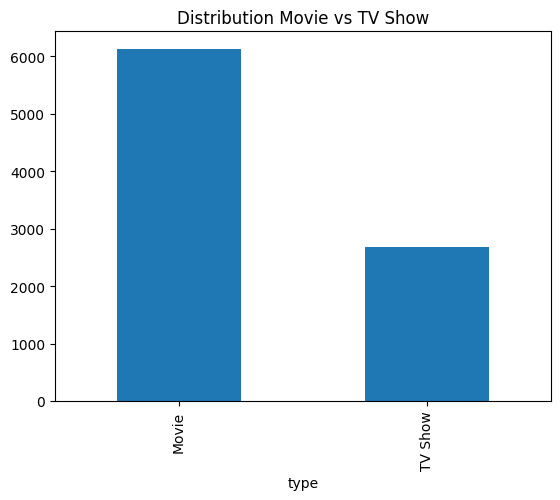

In [8]:
print(df["type"].value_counts(normalize=True))
df["type"].value_counts().plot(kind="bar", title="Distribution Movie vs TV Show")


In [9]:
print(df.describe(include="all"))


       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   
mean       NaN    NaN     NaN            NaN                 NaN   
std        NaN    NaN     NaN            NaN                 NaN   
min        NaN    NaN     NaN            NaN                 NaN   
25%        NaN    NaN     NaN            NaN                 NaN   
50%        NaN    NaN     NaN            NaN                 NaN   
75%        NaN    NaN     NaN            NaN                 NaN   
max        NaN    NaN     NaN            NaN                 NaN   

              country       date_added  release_year rating  duration  \
count            7976             8797   8807.000000   8803      8804   
unique            748             176

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


<Axes: title={'center': 'Taux de valeurs manquantes (%)'}>

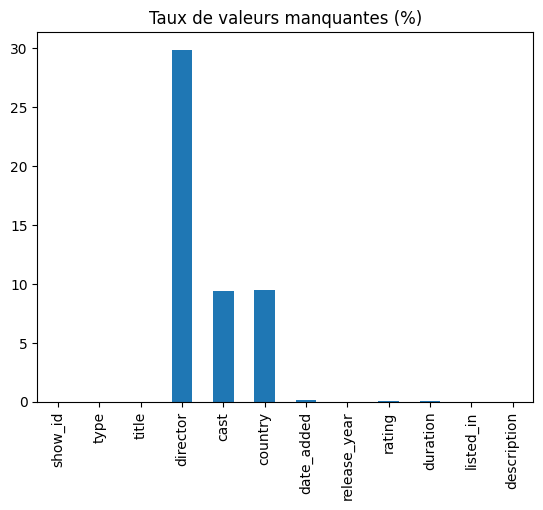

In [10]:
missing = df.isnull().mean() * 100
print(missing)
missing.plot(kind="bar", title="Taux de valeurs manquantes (%)")


In [11]:
#pretraitement

# Convert 'date_added' to datetime and extract features
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month
df['added_day_of_week'] = df['date_added'].dt.dayofweek

# Imputation numérique (now includes newly created 'added_*' columns)
for col in df.select_dtypes(include=["number", "float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Imputation catégorielle
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Function to extract numerical duration and identify TV shows
def extract_duration_and_type_flag(row):
    duration_str = str(row['duration'])
    is_tv_show = 0 # Default to Movie
    duration_in_minutes = 0

    if 'min' in duration_str:
        duration_in_minutes = int(duration_str.replace(' min', ''))
    elif 'Season' in duration_str:
        is_tv_show = 1 # Mark as TV Show
        try:
            num_seasons = int(duration_str.split(' ')[0])
            # Estimate: 1 season = 10 episodes * 45 minutes/episode = 450 minutes
            duration_in_minutes = num_seasons * 450
        except ValueError:
            duration_in_minutes = 450 # Default for malformed season strings (assume 1 season)
    return pd.Series([duration_in_minutes, is_tv_show], index=['duration_value', 'is_tv_show_duration_flag'])

# Apply the function to create new columns
df[['duration_value', 'is_tv_show_duration_flag']] = df.apply(extract_duration_and_type_flag, axis=1)

In [12]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Apply Label Encoding to 'type'
df['type_encoded'] = LabelEncoder().fit_transform(df['type'])

# Apply Label Encoding to 'rating'
rating_encoder = LabelEncoder() # Store the encoder
df['rating_encoded'] = rating_encoder.fit_transform(df['rating'])

# Apply One-Hot Encoding to 'country'
df = pd.get_dummies(df, columns=['country'], drop_first=True, prefix='country')

# Display first few rows to show changes
print("DataFrame after encoding:")
display(df.head())

# Explanation for other columns that are not directly encoded:
# Columns like 'show_id', 'title', 'director', 'cast', 'listed_in', and 'description'
# have been excluded from direct Label or One-Hot Encoding in this step because:
# - 'show_id' and 'title' are unique identifiers or have very high cardinality,
#   making simple encoding inefficient or inappropriate.
# - 'director', 'cast', and 'description' are free-form text or lists of names,
#   which typically require advanced text processing techniques (e.g., TF-IDF, embeddings,
#   topic modeling) for effective feature extraction.
# - 'listed_in' is a multi-label categorical feature (e.g., "Dramas, International Movies"),
#   which requires specific handling such as MultiLabelBinarizer or splitting into
#   individual genres and then encoding them, if specific genres are important for analysis.
# These complex features require more tailored approaches beyond simple encoding methods.

DataFrame after encoding:


,show_id,type,title,director,cast,date_added,release_year,rating,duration,listed_in,...,"country_Uruguay, Argentina, Germany, Spain","country_Uruguay, Argentina, Spain","country_Uruguay, Germany","country_Uruguay, Guatemala","country_Uruguay, Spain, Mexico",country_Venezuela,"country_Venezuela, Colombia",country_Vietnam,country_West Germany,country_Zimbabwe
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,2021-09-25,2020,PG-13,90 min,Documentaries,...,False,False,False,False,False,False,False,False,False,False
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",...,False,False,False,False,False,False,False,False,False,False
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",...,False,False,False,False,False,False,False,False,False,False
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",...,False,False,False,False,False,False,False,False,False,False
4,s5,TV Show,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",...,False,False,False,False,False,False,False,False,False,False


In [13]:
print("Shape of DataFrame after encoding:", df.shape)
print("Info of DataFrame after encoding:")
df.info()
print("First 5 rows of DataFrame after encoding:")
display(df.head())

Shape of DataFrame after encoding: (8807, 765)
Info of DataFrame after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Columns: 765 entries, show_id to country_Zimbabwe
dtypes: bool(747), datetime64[ns](1), float64(3), int64(5), object(9)
memory usage: 7.5+ MB
First 5 rows of DataFrame after encoding:


,show_id,type,title,director,cast,date_added,release_year,rating,duration,listed_in,...,"country_Uruguay, Argentina, Germany, Spain","country_Uruguay, Argentina, Spain","country_Uruguay, Germany","country_Uruguay, Guatemala","country_Uruguay, Spain, Mexico",country_Venezuela,"country_Venezuela, Colombia",country_Vietnam,country_West Germany,country_Zimbabwe
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,2021-09-25,2020,PG-13,90 min,Documentaries,...,False,False,False,False,False,False,False,False,False,False
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",...,False,False,False,False,False,False,False,False,False,False
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",...,False,False,False,False,False,False,False,False,False,False
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",...,False,False,False,False,False,False,False,False,False,False
4,s5,TV Show,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",...,False,False,False,False,False,False,False,False,False,False


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
# Drop original categorical columns, date_added (datetime), and the target 'type_encoded'
columns_to_drop = [
    'show_id', 'type', 'title', 'director', 'cast', 'date_added',
    'rating', 'duration', 'listed_in', 'description'
]

X = df.drop(columns=columns_to_drop + ['type_encoded'])
y = df['type_encoded']

# Split the data into training and testing sets
# Using a common test_size (e.g., 20%) and random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Identify columns to scale (all numerical and boolean features)
numerical_cols = X_train.select_dtypes(include=['number', 'bool']).columns

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("\nFirst 5 rows of X_train_scaled (after scaling):")
display(X_train_scaled.head())
print("\nFirst 5 rows of X_test_scaled (after scaling):")
display(X_test_scaled.head())

print("\nFirst 5 rows of y_train:")
display(y_train.head())
print("\nFirst 5 rows of y_test:")
display(y_test.head())

Shape of X_train_scaled: (7045, 754)
Shape of X_test_scaled: (1762, 754)

First 5 rows of X_train_scaled (after scaling):


,release_year,added_year,added_month,added_day_of_week,duration_value,is_tv_show_duration_flag,rating_encoded,"country_, South Korea",country_Argentina,"country_Argentina, Brazil, France, Poland, Germany, Denmark",...,"country_Uruguay, Argentina, Germany, Spain","country_Uruguay, Argentina, Spain","country_Uruguay, Germany","country_Uruguay, Guatemala","country_Uruguay, Spain, Mexico",country_Venezuela,"country_Venezuela, Colombia",country_Vietnam,country_West Germany,country_Zimbabwe
5471,0.319483,-1.226808,-0.481362,0.568417,-0.454614,-0.658306,-0.519605,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
530,0.087602,1.361069,0.108155,-1.175703,1.152121,1.519050,-0.007917,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
5594,0.319483,-1.226808,-1.365637,-1.175703,-0.478099,-0.658306,-0.519605,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
996,0.783246,1.361069,-0.776120,-0.012956,-0.382204,-0.658306,0.503771,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
6951,0.435424,-0.579839,-0.186604,0.568417,1.152121,1.519050,0.503771,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915



First 5 rows of X_test_scaled (after scaling):


,release_year,added_year,added_month,added_day_of_week,duration_value,is_tv_show_duration_flag,rating_encoded,"country_, South Korea",country_Argentina,"country_Argentina, Brazil, France, Poland, Germany, Denmark",...,"country_Uruguay, Argentina, Germany, Spain","country_Uruguay, Argentina, Spain","country_Uruguay, Germany","country_Uruguay, Guatemala","country_Uruguay, Spain, Mexico",country_Venezuela,"country_Venezuela, Colombia",country_Vietnam,country_West Germany,country_Zimbabwe
4970,0.435424,-0.579839,-1.070879,0.568417,-0.409602,-0.658306,0.503771,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
3362,0.551365,0.067131,0.992430,-1.175703,-0.485927,-0.658306,0.503771,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
5494,0.319483,-1.226808,-0.481362,0.568417,2.032792,1.519050,1.527148,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
1688,0.667306,0.714100,1.287189,-1.175703,0.271450,1.519050,0.503771,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915
1349,-0.260221,1.361069,-1.365637,-0.594329,0.271450,1.519050,0.503771,-0.011915,-0.08107,-0.011915,...,-0.011915,0.0,0.0,-0.011915,0.0,-0.011915,-0.011915,-0.02665,-0.011915,-0.011915



First 5 rows of y_train:


,type_encoded
5471,0
530,1
5594,0
996,0
6951,1



First 5 rows of y_test:


,type_encoded
4970,0
3362,0
5494,1
1688,1
1349,1


### Convert to PyTorch Tensors and Create DataLoaders

Now, we'll convert our scaled training and testing data into PyTorch tensors and then create `DataLoader` objects. `DataLoader`s are essential for iterating over the dataset in batches, which is a standard practice in deep learning training.

In [15]:
from torch.utils.data import TensorDataset, DataLoader
import torch

# Convert DataFrames/Series to NumPy arrays, then to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

# For BCEWithLogitsLoss, target needs to be float32 and reshaped to match output (batch_size, 1)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Define batch size
batch_size = 64 # A common batch size, can be adjusted

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

X_train_tensor shape: torch.Size([7045, 754])
y_train_tensor shape: torch.Size([7045, 1])
X_test_tensor shape: torch.Size([1762, 754])
y_test_tensor shape: torch.Size([1762, 1])
Number of batches in training loader: 111
Number of batches in test loader: 28


In [16]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden = nn.Linear(input_size, hidden_size)   # input → hidden
        self.output = nn.Linear(hidden_size, output_size)  # hidden → output

    def forward(self, x):
        h = F.relu(self.hidden(x))   # apply hidden layer + ReLU
        out = self.output(h)         # apply output layer
        return out


In [17]:
input_size = X_train.shape[1]   # number of features
hidden_size = 64                # chosen capacity
output_size = 1                 # 1 for binary classification (Movie vs TV Show)

model = MLP(input_size, hidden_size, output_size)

In [18]:
loss_fn = nn.BCEWithLogitsLoss()

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [20]:
print(X_train_tensor.shape)   # should be (N, num_features)
print(y_train_tensor.shape)   # should be (N,)
print(y_train_tensor.dtype)   # should be torch.int64 (long)

torch.Size([7045, 754])
torch.Size([7045, 1])
torch.float32


In [21]:
for epoch in range(10):  # 10 epochs
    for features, labels in train_loader:
        outputs = model(features)          # forward pass
        loss = loss_fn(outputs, labels)    # compute loss

        optimizer.zero_grad()              # reset gradients
        loss.backward()                    # backpropagation
        optimizer.step()                   # update weights

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.5144
Epoch 2, Loss: 0.0949
Epoch 3, Loss: 0.0582
Epoch 4, Loss: 0.0105
Epoch 5, Loss: 0.0228
Epoch 6, Loss: 0.0046
Epoch 7, Loss: 0.0013
Epoch 8, Loss: 0.0088
Epoch 9, Loss: 0.0006
Epoch 10, Loss: 0.0003


In [39]:
train_losses = []
val_losses = []

In [40]:
for epoch in range(10):  # 10 epochs
    model.train() # Set model to training mode
    current_train_loss = 0.0
    for features, labels in train_loader:
        outputs = model(features)          # forward pass
        loss = loss_fn(outputs, labels)    # compute loss

        optimizer.zero_grad()              # reset gradients
        loss.backward()                    # backpropagation
        optimizer.step()                   # update weights
        current_train_loss += loss.item()

    avg_train_loss = current_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval() # Set model to evaluation mode
    current_val_loss = 0.0
    with torch.no_grad():
        for features, labels in test_loader:
            outputs = model(features)
            loss = loss_fn(outputs, labels)
            current_val_loss += loss.item()

    avg_val_loss = current_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

Epoch 1, Training Loss: 0.4968, Validation Loss: 0.2665
Epoch 2, Training Loss: 0.1578, Validation Loss: 0.0815
Epoch 3, Training Loss: 0.0468, Validation Loss: 0.0390
Epoch 4, Training Loss: 0.0215, Validation Loss: 0.0276
Epoch 5, Training Loss: 0.0130, Validation Loss: 0.0227
Epoch 6, Training Loss: 0.0088, Validation Loss: 0.0198
Epoch 7, Training Loss: 0.0066, Validation Loss: 0.0185
Epoch 8, Training Loss: 0.0051, Validation Loss: 0.0171
Epoch 9, Training Loss: 0.0041, Validation Loss: 0.0162
Epoch 10, Training Loss: 0.0034, Validation Loss: 0.0154


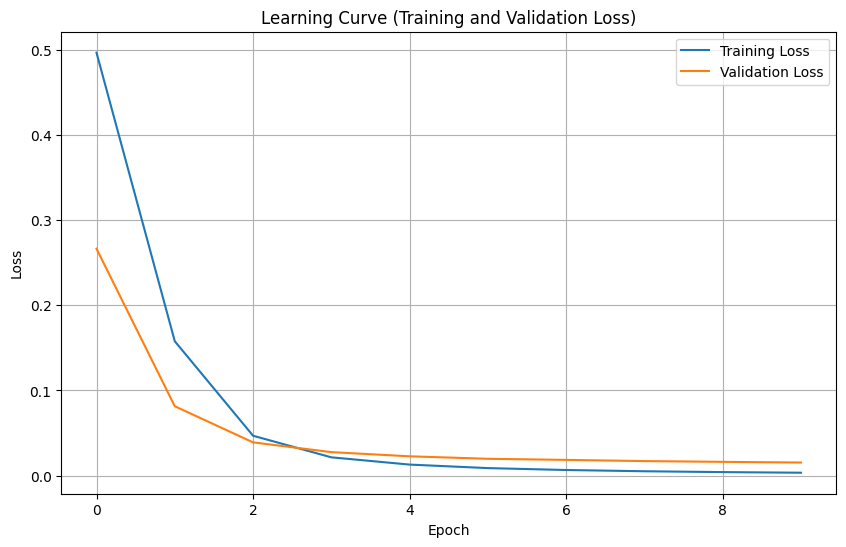

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve (Training and Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
print(f"Number of NaN values in X_train_tensor: {torch.isnan(X_train_tensor).sum()}")
print(f"Number of Inf values in X_train_tensor: {torch.isinf(X_train_tensor).sum()}")

Number of NaN values in X_train_tensor: 0
Number of Inf values in X_train_tensor: 0


In [23]:
correct, total = 0, 0
with torch.no_grad():
    for features, labels in test_loader:
        outputs = model(features)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid and then a threshold
        predicted = (torch.sigmoid(outputs) > 0.5).float() # Threshold at 0.5
        total += labels.size(0)               # number of samples in batch
        correct += (predicted == labels).sum().item()  # count matches

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.55%


Test Accuracy: 99.55%


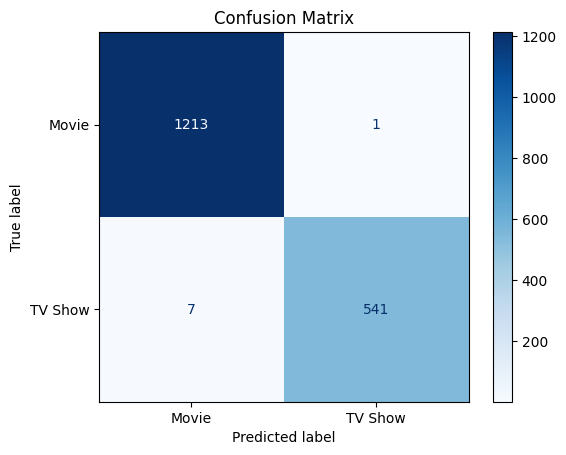

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

model.eval() # Set model to evaluation mode
all_predictions = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        outputs = model(features)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid and then a threshold
        predicted = (torch.sigmoid(outputs) > 0.5).float() # Threshold at 0.5
        all_predictions.extend(predicted.cpu().numpy().flatten()) # Move to CPU and flatten
        all_labels.extend(labels.cpu().numpy().flatten()) # Move to CPU and flatten

# Calculate accuracy
accuracy = 100 * np.sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
print(f"Test Accuracy: {accuracy:.2f}%")

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Movie', 'TV Show'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### Interactive Prediction

Now you can enter details for a new movie or TV show, and the model will predict its type.

In [24]:
import numpy as np

def predict_new_entry(model, scaler, rating_encoder, X_columns):
    print("\nEnter details for a new entry:")

    # Collect user input
    release_year = int(input("Release Year (e.g., 2021): "))
    duration_str = input("Duration (e.g., '90 min' or '2 Seasons'): ")
    rating_input = input("Rating (e.g., 'TV-MA', 'PG-13', 'R'): ")
    country_input = input("Country (e.g., 'United States', 'India', 'Canada'): ")

    # Simulate current date for 'date_added' if needed for derived features
    # For simplicity, we'll use fixed values or an approximation based on the dataset's 'added_year' range
    # In a real-world scenario, you might use datetime.now()
    added_year_sim = 2021 # Assuming the data's latest added_year
    added_month_sim = 9 # Median month from dataset
    added_day_of_week_sim = 4 # Median day of week from dataset

    # --- Preprocessing steps (mimicking what was done for df) ---
    processed_data = {}

    # 1. Duration processing
    duration_value = 0
    is_tv_show_duration_flag = 0
    if 'min' in duration_str:
        duration_value = int(duration_str.replace(' min', ''))
    elif 'Season' in duration_str:
        is_tv_show_duration_flag = 1
        try:
            num_seasons = int(duration_str.split(' ')[0])
            duration_value = num_seasons * 450 # Estimate
        except ValueError:
            duration_value = 450 # Default for malformed

    processed_data['duration_value'] = duration_value
    processed_data['is_tv_show_duration_flag'] = is_tv_show_duration_flag
    processed_data['release_year'] = release_year
    processed_data['added_year'] = float(added_year_sim)
    processed_data['added_month'] = float(added_month_sim)
    processed_data['added_day_of_week'] = float(added_day_of_week_sim)

    # 2. Rating encoding
    # Strip whitespace from rating_input to handle accidental spaces
    rating_input_cleaned = rating_input.strip()
    try:
        rating_encoded_value = rating_encoder.transform([rating_input_cleaned])[0]
    except ValueError:
        # Handle unseen rating categories by assigning a default or the most frequent one
        # For simplicity, we'll assign the mode of the training ratings
        print(f"Warning: Rating '{rating_input_cleaned}' not seen during training. Assigning default.")
        rating_encoded_value = rating_encoder.transform([rating_encoder.inverse_transform([df['rating_encoded'].mode()[0]])[0]])[0]
    processed_data['rating_encoded'] = rating_encoded_value

    # 3. Country one-hot encoding
    # Create a dummy row with all country features set to 0 initially
    country_cols = [col for col in X_columns if col.startswith('country_')]
    for col in country_cols:
        processed_data[col] = False # Or 0 for numerical conversion

    # Set the specific country's column to True/1
    country_col_name = f'country_{country_input}'
    if country_col_name in country_cols:
        processed_data[country_col_name] = True
    else:
        print(f"Warning: Country '{country_input}' not seen during training. Will not be one-hot encoded.")

    # Create a DataFrame for the single input row, ensuring column order and types match X_train_scaled
    # We need to explicitly order columns as per X_train_scaled to match the model's input
    input_df = pd.DataFrame([processed_data], columns=X_columns)
    # Ensure boolean columns are correctly handled (converted to 0/1 for scaling)
    for col in input_df.select_dtypes(include=['bool']).columns:
        input_df[col] = input_df[col].astype(int)

    # 4. Scaling numerical features
    numerical_cols = input_df.select_dtypes(include=['number']).columns
    input_scaled = input_df.copy()
    input_scaled[numerical_cols] = scaler.transform(input_df[numerical_cols])

    # Convert to PyTorch tensor
    input_tensor = torch.tensor(input_scaled.values, dtype=torch.float32)

    # Make prediction
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        output = model(input_tensor)
        prediction = (torch.sigmoid(output) > 0.5).float()

    # Interpret result
    if prediction.item() == 0:
        print("\nPrediction: Movie")
    else:
        print("\nPrediction: TV Show")

# Get the list of column names from X_train_scaled to ensure consistent feature order
X_columns = X_train_scaled.columns.tolist()

# Run the prediction function
predict_new_entry(model, scaler, rating_encoder, X_columns)



Enter details for a new entry:
Release Year (e.g., 2021): 1980
Duration (e.g., '90 min' or '2 Seasons'): 90 min
Rating (e.g., 'TV-MA', 'PG-13', 'R'): TV-MA
Country (e.g., 'United States', 'India', 'Canada'): India

Prediction: Movie


## Resources

This project utilized the following resources and tools:

*   **Dataset:**
    *   `Netflix Shows` dataset from Kaggle (`shivamb/netflix-shows`).

*   **Libraries & Frameworks:**
    *   `pandas`: For data manipulation and analysis.
    *   `scikit-learn (sklearn)`: For data preprocessing (e.g., `LabelEncoder`, `StandardScaler`, `train_test_split`).
    *   `torch` (PyTorch): The deep learning framework used for building, training, and evaluating the Multi-Layer Perceptron (MLP) model.
    *   `matplotlib` and `seaborn`: For data visualization (if any specific plots were added for EDA).
    *   `kagglehub`: For programmatic access to Kaggle datasets.

*   **Development Environment:**
    *   Google Colaboratory (Colab): The interactive notebook environment used for development and execution.

*   **Core Concepts:**
    *   Data Preprocessing: Handling missing values, feature engineering (e.g., date extraction, duration parsing), categorical encoding (Label Encoding, One-Hot Encoding), and feature scaling.
    *   Deep Learning: Multi-Layer Perceptron (MLP) architecture, Binary Cross-Entropy with Logits Loss, Adam optimizer, training loops, and evaluation metrics (accuracy).
    *   Interactive Prediction: Demonstrating real-time model inference with user input.

In [31]:
import torchsummary

In [38]:
# Re-initialize model (assuming input_size, hidden_size, output_size, and MLP class are already defined)
# This is necessary if the runtime disconnected or previous cells weren't executed.

input_size = X_train.shape[1]
hidden_size = 64
output_size = 1

model = MLP(input_size, hidden_size, output_size)
# Move the model to CPU for torchsummary compatibility
model.to('cpu')

# Re-initialize the optimizer to point to the new model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print('Model and Optimizer re-initialized successfully and model moved to CPU.')

Model and Optimizer re-initialized successfully and model moved to CPU.


In [34]:
# Display model summary

torchsummary.summary(model, input_size=(input_size,), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]          48,320
            Linear-2                    [-1, 1]              65
Total params: 48,385
Trainable params: 48,385
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.18
Estimated Total Size (MB): 0.19
----------------------------------------------------------------
